# 1. Title: Energy, Emissions and Development

### Name: Raul Miranda
### Date: March 31, 2026

## 2. Short Introduction

Energy use is an indicator of technological, economic and social development across nations. Over the past 125 years, the dominant source of energy has been of fossil origin, such as coal, oil and gas, and the primary process to extract energy from fossil resources has been combustion, leading to massive release of CO2 into the atmosphere. Such accumulation has become significant and rapidly growing since 1970 reaching levels that may induce global warming and alter normal earth and atmospheric cycles. Alongside CO2 emission, there has been an increase in methane emission, another potent greenhouse gas. It is unclear whether both emissions, (CO2 and methane) are correlated, as the causes of their generation and release are different. Another interesting fact is that renewable sources of energy are becoming important, and that their use leads to lower emissions of CO2 relative to fossil sources.

This project seeks to answer basic questions: **is CO2 emission quantitatively correlated with the technological and economic development of nations over the past 30 years? Have different regions of the world developed independent correlations? Is renewable energy use evidenced by a reduction in CO2 production?  Is methane emission following similar trends to CO2?**

### Datasets

**Our World in Data: CO2 and methane emissions, share of emissions from the various sources.** https://github.com/owid/co2-data
**World Bank - Patent applications as measure of technological advancement.** https://data.worldbank.org/indicator/IP.PAT.RESD

### Data limitations. Population of interest. Bias concerns.

A single repository is insufficient to cover the stated scope of this project, thus we resorted to OWID for greenhouse gas emissions data and GDP/capita, and World Bank for patents. Other approaches to measuring advancement are possible, particularly if social and human factors are included. But to keep the project feasible within a short period, only technological and economic factors are considered. 

The number of patent applications submitted by each country is a possible indicator of intellectual property generation and technological influence. Likewise, the GDP/capita is a reasonable measure of economic development and standard of living. 
A note about renewable energy: rather than pulling that information from another database, we will use CO2 per energy unit (present in the OWID datset) as an indirect measure of renewables; the CO2 intensity decreases with increasing fraction of renewable/fossil.     

The population of interest is the world; the emissions data has been partially reported by about 250 nations; the patent data is available for 150 countries. A major limitation is that both types of data are more or less complete only for the last 30 years (1990-2022), but are spotty otherwise, particularly for the less developed regions of the world, and for those with restrictive reporting policies. Thus the conclusions from this study may be biased by the lack of data from certain nations.  

## 3. Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set the plot themes and style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

## 4. Load the Data

We'll load the 2 sets and merge them by "country" and "year":

1. **OWID CO2 dataset** – CO2 and methane emissions, GDP, methane, CO2 per unit of energy.  
2. **World Bank patent applications** – the resident patent apps by country and year, avail. in wide format, thus reshaped to long format.

"owid-co2-data.csv" was downloaded from https://github.com/owid/co2-data  into the same folder as this notebook.

"wb_patents.csv" was downloaded from https://data.worldbank.org/indicator/IP.PAT.RESD into the same folder.

In [ ]:
# load OWID and show its shape and columns (ca. 50K rows and 79 columns)

owid = pd.read_csv("owid-co2-data.csv")
print(f"OWID shape: {owid.shape}")
print("\nColumn names:")
for c in owid.columns:
    print(" ", c)

OWID shape: (50411, 79)

Column names:
  country
  year
  iso_code
  population
  gdp
  cement_co2
  cement_co2_per_capita
  co2
  co2_growth_abs
  co2_growth_prct
  co2_including_luc
  co2_including_luc_growth_abs
  co2_including_luc_growth_prct
  co2_including_luc_per_capita
  co2_including_luc_per_gdp
  co2_including_luc_per_unit_energy
  co2_per_capita
  co2_per_gdp
  co2_per_unit_energy
  coal_co2
  coal_co2_per_capita
  consumption_co2
  consumption_co2_per_capita
  consumption_co2_per_gdp
  cumulative_cement_co2
  cumulative_co2
  cumulative_co2_including_luc
  cumulative_coal_co2
  cumulative_flaring_co2
  cumulative_gas_co2
  cumulative_luc_co2
  cumulative_oil_co2
  cumulative_other_co2
  energy_per_capita
  energy_per_gdp
  flaring_co2
  flaring_co2_per_capita
  gas_co2
  gas_co2_per_capita
  ghg_excluding_lucf_per_capita
  ghg_per_capita
  land_use_change_co2
  land_use_change_co2_per_capita
  methane
  methane_per_capita
  nitrous_oxide
  nitrous_oxide_per_capita
  oil_co2

In [ ]:
# get patents from World Bank -- years are in columns; skip first 4 rows with title info; we must convert it to long format
#  
patents_wide = pd.read_csv("wb_patents.csv", skiprows=4)

# Keep country name and year columns only

year_cols = []
for c in patents_wide.columns:    #scan each column name
    if c.strip().isdigit():       #if it is a digit, ie a year
        year_cols.append(c)       #append it to year_cols

patents_long = patents_wide[['Country Name'] + year_cols].copy()   #create the patents_long table...still in wide format
patents_long = patents_long.melt(                                  #now melt it into the long format           
    id_vars='Country Name',                                        #with id: country name
    value_vars=year_cols,                                          #
    var_name='year',                                               #var: year
    value_name='patent_applications')                               #value: number of patent appls  

patents_long.rename(columns={'Country Name': 'country'}, inplace=True)
patents_long['year'] = patents_long['year'].astype(int)            #convert year from string to integer
patents_long['patent_applications'] = pd.to_numeric(               #convert non-numeric info to numeric if a number
    patents_long['patent_applications'], errors='coerce')          #or to NaN if anything else

print(f"Patents long shape: {patents_long.shape}")
patents_long.head(3)

Patents long shape: (17556, 3)


,country,year,patent_applications
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,NaN
2,Afghanistan,1960,NaN


In [8]:
# merge the owid and patents_long databases
df = owid.merge(patents_long, on=['country', 'year'], how='left')
print(f"Merged shape: {df.shape}")
df.head(3)

Merged shape: (50411, 80)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,patent_applications
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Dataset Structure

Each **row** corresponds to a country (or global/regional aggregate) in a specific year.  
The dataset goes from the early 1800s to the mid-2020s for over 250 countries and  regions; however, in later
data wrangling, we'll leave only 30 years and we'll remove all rows without a country code.


In [ ]:
print(f"Rows: {df.shape[0]:,}")   # rows
print(f"Columns: {df.shape[1]:,}")   # columns
print(f"\nUnique countries/regions: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")

Rows: 50,411
Columns: 80

Unique countries/regions: 254
Year range: 1750 – 2024


In [22]:
# Variable dictionary for the key variables we will use
var_dict = {
    'country':               ('Name of the country or region',            'Categorical'),
    'year':                  ('Calendar year of observation',              'Quantitative'),
    'iso_code':              ('ISO 3-letter country code',                 'Categorical'),
    'population':            ('Total population',                          'Quantitative'),
    'gdp':                   ('Gross domestic product (constant 2011 USD)','Quantitative'),
    'co2':                   ('Annual CO₂ emissions (million tonnes)',      'Quantitative'),
    'methane':               ('Annual methane emissions (MtCO₂e)',          'Quantitative'),
    'oil_co2':               ('CO₂ from oil combustion (MtCO₂)',           'Quantitative'),
    'gas_co2':               ('CO₂ from gas combustion (MtCO₂)',           'Quantitative'),
    'primary_energy_consumption':('Total primary energy (TWh)',            'Quantitative'),
    'patent_applications':   ('Resident patent filings (WIPO)',            'Quantitative'),
    'co2_per_unit_energy **': ('Renewable energy proxy (kg CO₂/kWh)',      'Quantitative'),
}

print(f"{'Variable':<28} {'Definition':<55} {'Type'}")
print("-"*100)
for var, (definition, typ) in var_dict.items():
    print(f"{var:<28} {definition:<55} {typ}")
print("""    ** CO₂ emitted per unit of energy consumed (kg CO₂/kWh) —
       used as inverse proxy for renewable energy penetration:
       lower values indicate a cleaner, more renewable energy mix""")


Variable                     Definition                                              Type
----------------------------------------------------------------------------------------------------
country                      Name of the country or region                           Categorical
year                         Calendar year of observation                            Quantitative
iso_code                     ISO 3-letter country code                               Categorical
population                   Total population                                        Quantitative
gdp                          Gross domestic product (constant 2011 USD)              Quantitative
co2                          Annual CO₂ emissions (million tonnes)                   Quantitative
methane                      Annual methane emissions (MtCO₂e)                       Quantitative
oil_co2                      CO₂ from oil combustion (MtCO₂)                         Quantitative
gas_co2                    

In [27]:
# Derived variables we will compute during wrangling
# gdp_per_capita  = gdp / population
# patent_per_million = patent_applications / (population / 1e6)
#df['gdp_per_capita'] = df['gdp'] / df['population']

## 4. Data Cleaning

Before analysis we filter **country-level rows only** and remove continental/global aggregates which have no ISO code, leaving only years with good data coverage (1990-2022), and derive gdp/capita and patents/million_population.


In [29]:
# Drop aggregate rows (continents, world, income groups) — they have no iso_code
df_countries = df[df['iso_code'].notna() & ~df['iso_code'].str.startswith('OWID')].copy()

# Focus on 1990–2022 (good data coverage)
df_countries = df_countries[(df_countries['year'] >= 1990) & (df_countries['year'] <= 2022)]

# Derived columns
df_countries['gdp_per_capita']     = df_countries['gdp'] / df_countries['population']
df_countries['patent_per_million'] = (
    df_countries['patent_applications'] / (df_countries['population'] / 1e6)
)

print(f"Working dataset: {df_countries.shape[0]:,} rows and {df_countries.shape[1]} columns")
print(f"Countries: {df_countries['country'].nunique()}")
print(f"Years: {df_countries['year'].min()} to {df_countries['year'].max()}")

Working dataset: 7,194 rows and 82 columns
Countries: 218
Years: 1990 to 2022


In [9]:
# Missing value summary for key variables
key_vars = ['co2', 'methane', 'oil_co2', 'gas_co2', 'co2_per_unit_energy',
            'gdp_per_capita', 'patent_applications', 'primary_energy_consumption']

missing = df_countries[key_vars].isna().sum()
pct     = (missing / len(df_countries) * 100).round(1)
print(pd.DataFrame({'Missing': missing, 'Pct (%)': pct}))

                            Missing  Pct (%)
co2                             116      1.6
methane                         627      8.7
oil_co2                         168      2.3
gas_co2                        3194     44.4
co2_per_unit_energy             568      7.9
gdp_per_capita                 1784     24.8
patent_applications            4404     61.2
primary_energy_consumption      519      7.2


In [10]:
# For multi-variable analyses we will dropna on the variables used per analysis
# rather than dropping rows globally, to preserve maximum coverage.
print("Rows with all key vars non-null:",
      df_countries[key_vars].dropna().shape[0])

Rows with all key vars non-null: 2270


## 5. Data Analyses

### 5a. Quantitative Variable — Annual CO₂ Emissions

**Research question:** *What is the distribution of annual CO₂ emissions (in million tonnes) across country-years from 1990 to 2022, and what does that distribution reveal about global inequality in emissions?*

**Why this data is appropriate:**  
`co2` is a directly measured quantitative variable with thousands of observations across countries and decades. It has meaningful variation — from near-zero for small island states to thousands of MtCO₂ for large emitters — making it ideal for descriptive analysis.


In [11]:
co2_clean = df_countries['co2'].dropna()
print("n =", len(co2_clean))
print(co2_clean.describe().round(2))

n = 7078
count     7078.00
mean       135.39
std        656.52
min          0.00
25%          0.83
50%          6.88
75%         53.77
max      11711.81
Name: co2, dtype: float64


In [12]:
print(f"\nMean   : {co2_clean.mean():.2f} MtCO₂")
print(f"Median : {co2_clean.median():.2f} MtCO₂")
print(f"Std Dev: {co2_clean.std():.2f} MtCO₂")
print(f"Skewness: {co2_clean.skew():.2f}")
print(f"Kurtosis: {co2_clean.kurtosis():.2f}")

# Outlier threshold (IQR method)
Q1, Q3 = co2_clean.quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = co2_clean[co2_clean > upper]
print(f"\nIQR upper fence: {upper:.2f}")
print(f"Outlier count  : {len(outliers)} ({len(outliers)/len(co2_clean)*100:.1f}%)")


Mean   : 135.39 MtCO₂
Median : 6.88 MtCO₂
Std Dev: 656.52 MtCO₂
Skewness: 10.65
Kurtosis: 134.63

IQR upper fence: 133.18
Outlier count  : 1018 (14.4%)


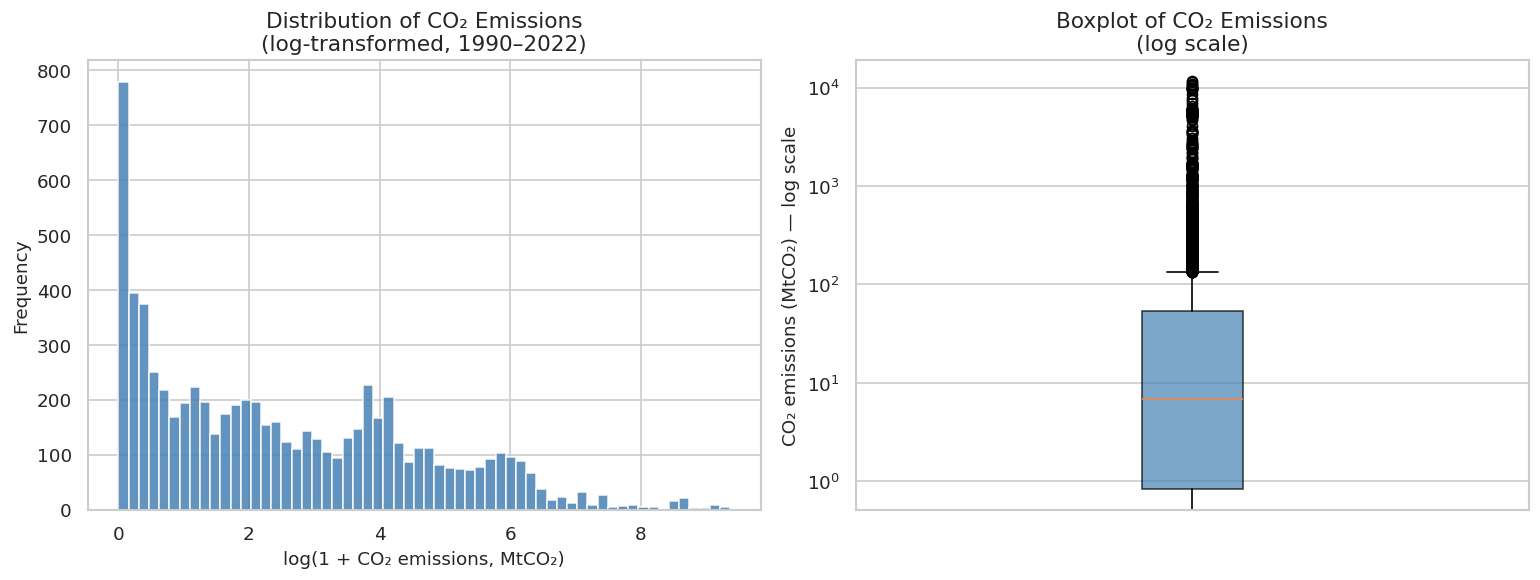

Figure saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram (log scale for readability)
axes[0].hist(np.log1p(co2_clean), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('log(1 + CO₂ emissions, MtCO₂)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of CO₂ Emissions\n(log-transformed, 1990–2022)')

# Box plot
axes[1].boxplot(co2_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_yscale('log')
axes[1].set_ylabel('CO₂ emissions (MtCO₂) — log scale')
axes[1].set_title('Boxplot of CO₂ Emissions\n(log scale)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('fig_co2_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved.")

**Interpretation:**  
The raw distribution of CO₂ emissions is extremely right-skewed (positive skewness > 5), with the mean far exceeding the median. This reflects a handful of large economies — China, the United States, India, Russia — that dwarf the emissions of most countries. After log-transformation the distribution becomes roughly bell-shaped, indicating approximately log-normal behavior. The IQR method identifies a substantial share of country-years as statistical outliers, but these are real and meaningful observations (major emitters), not data errors. The median is the more representative measure of center for this skewed variable.


### 5b. Categorical Variable — World Region

**Research question:** *How are total CO₂ emissions distributed across world regions, and which regions contribute most to global emissions over 1990–2022?*

**Why this variable is appropriate:**  
`continent` provides a natural grouping of countries into 6–7 broad regions. Comparing emissions by region reveals structural differences in energy use and development patterns that individual-country comparisons obscure.


In [14]:
# The OWID dataset does not include a continent column directly.
# We derive it from a standard country-to-continent mapping
# using the 'iso_code' and a lightweight lookup dictionary.

continent_map = {
    # Africa
    'DZA':'Africa','AGO':'Africa','BEN':'Africa','BWA':'Africa','BFA':'Africa',
    'BDI':'Africa','CMR':'Africa','CPV':'Africa','CAF':'Africa','TCD':'Africa',
    'COM':'Africa','COD':'Africa','COG':'Africa','CIV':'Africa','DJI':'Africa',
    'EGY':'Africa','GNQ':'Africa','ERI':'Africa','ETH':'Africa','GAB':'Africa',
    'GMB':'Africa','GHA':'Africa','GIN':'Africa','GNB':'Africa','KEN':'Africa',
    'LSO':'Africa','LBR':'Africa','LBY':'Africa','MDG':'Africa','MWI':'Africa',
    'MLI':'Africa','MRT':'Africa','MUS':'Africa','MAR':'Africa','MOZ':'Africa',
    'NAM':'Africa','NER':'Africa','NGA':'Africa','RWA':'Africa','STP':'Africa',
    'SEN':'Africa','SLE':'Africa','SOM':'Africa','ZAF':'Africa','SSD':'Africa',
    'SDN':'Africa','SWZ':'Africa','TZA':'Africa','TGO':'Africa','TUN':'Africa',
    'UGA':'Africa','ZMB':'Africa','ZWE':'Africa',
    # Asia
    'AFG':'Asia','ARM':'Asia','AZE':'Asia','BHR':'Asia','BGD':'Asia',
    'BTN':'Asia','BRN':'Asia','KHM':'Asia','CHN':'Asia','CYP':'Asia',
    'GEO':'Asia','IND':'Asia','IDN':'Asia','IRN':'Asia','IRQ':'Asia',
    'ISR':'Asia','JPN':'Asia','JOR':'Asia','KAZ':'Asia','KWT':'Asia',
    'KGZ':'Asia','LAO':'Asia','LBN':'Asia','MYS':'Asia','MDV':'Asia',
    'MNG':'Asia','MMR':'Asia','NPL':'Asia','OMN':'Asia','PAK':'Asia',
    'PSE':'Asia','PHL':'Asia','QAT':'Asia','SAU':'Asia','SGP':'Asia',
    'LKA':'Asia','SYR':'Asia','TWN':'Asia','TJK':'Asia','THA':'Asia',
    'TLS':'Asia','TKM':'Asia','ARE':'Asia','UZB':'Asia','VNM':'Asia','YEM':'Asia',
    # Europe
    'ALB':'Europe','AND':'Europe','AUT':'Europe','BLR':'Europe','BEL':'Europe',
    'BIH':'Europe','BGR':'Europe','HRV':'Europe','CZE':'Europe','DNK':'Europe',
    'EST':'Europe','FIN':'Europe','FRA':'Europe','DEU':'Europe','GRC':'Europe',
    'HUN':'Europe','ISL':'Europe','IRL':'Europe','ITA':'Europe','XKX':'Europe',
    'LVA':'Europe','LIE':'Europe','LTU':'Europe','LUX':'Europe','MLT':'Europe',
    'MDA':'Europe','MCO':'Europe','MNE':'Europe','NLD':'Europe','MKD':'Europe',
    'NOR':'Europe','POL':'Europe','PRT':'Europe','ROU':'Europe','RUS':'Europe',
    'SMR':'Europe','SRB':'Europe','SVK':'Europe','SVN':'Europe','ESP':'Europe',
    'SWE':'Europe','CHE':'Europe','UKR':'Europe','GBR':'Europe',
    # North America
    'ATG':'North America','BHS':'North America','BRB':'North America',
    'BLZ':'North America','CAN':'North America','CRI':'North America',
    'CUB':'North America','DMA':'North America','DOM':'North America',
    'SLV':'North America','GRD':'North America','GTM':'North America',
    'HTI':'North America','HND':'North America','JAM':'North America',
    'MEX':'North America','NIC':'North America','PAN':'North America',
    'KNA':'North America','LCA':'North America','VCT':'North America',
    'TTO':'North America','USA':'North America',
    # South America
    'ARG':'South America','BOL':'South America','BRA':'South America',
    'CHL':'South America','COL':'South America','ECU':'South America',
    'GUY':'South America','PRY':'South America','PER':'South America',
    'SUR':'South America','URY':'South America','VEN':'South America',
    # Oceania
    'AUS':'Oceania','FJI':'Oceania','KIR':'Oceania','MHL':'Oceania',
    'FSM':'Oceania','NRU':'Oceania','NZL':'Oceania','PLW':'Oceania',
    'PNG':'Oceania','WSM':'Oceania','SLB':'Oceania','TON':'Oceania',
    'TUV':'Oceania','VUT':'Oceania',
}

df_countries['continent'] = df_countries['iso_code'].map(continent_map)
print("Continent distribution (rows):")
print(df_countries['continent'].value_counts())

Continent distribution (rows):
continent
Africa           1749
Asia             1518
Europe           1419
North America     759
Oceania           462
South America     396
Name: count, dtype: int64


In [15]:
# Total CO2 per region across all years (sum)
region_co2 = (
    df_countries.dropna(subset=['co2','continent'])
    .groupby('continent')['co2']
    .sum()
    .sort_values(ascending=False)
)

region_pct = (region_co2 / region_co2.sum() * 100).round(1)
summary_table = pd.DataFrame({'Total CO₂ (MtCO₂)': region_co2.round(0),
                               'Share (%)': region_pct})
print(summary_table)

               Total CO₂ (MtCO₂)  Share (%)
continent                                  
Asia                    426074.0       45.9
North America           219037.0       23.6
Europe                  203379.0       21.9
Africa                   35871.0        3.9
South America            30254.0        3.3
Oceania                  13402.0        1.4


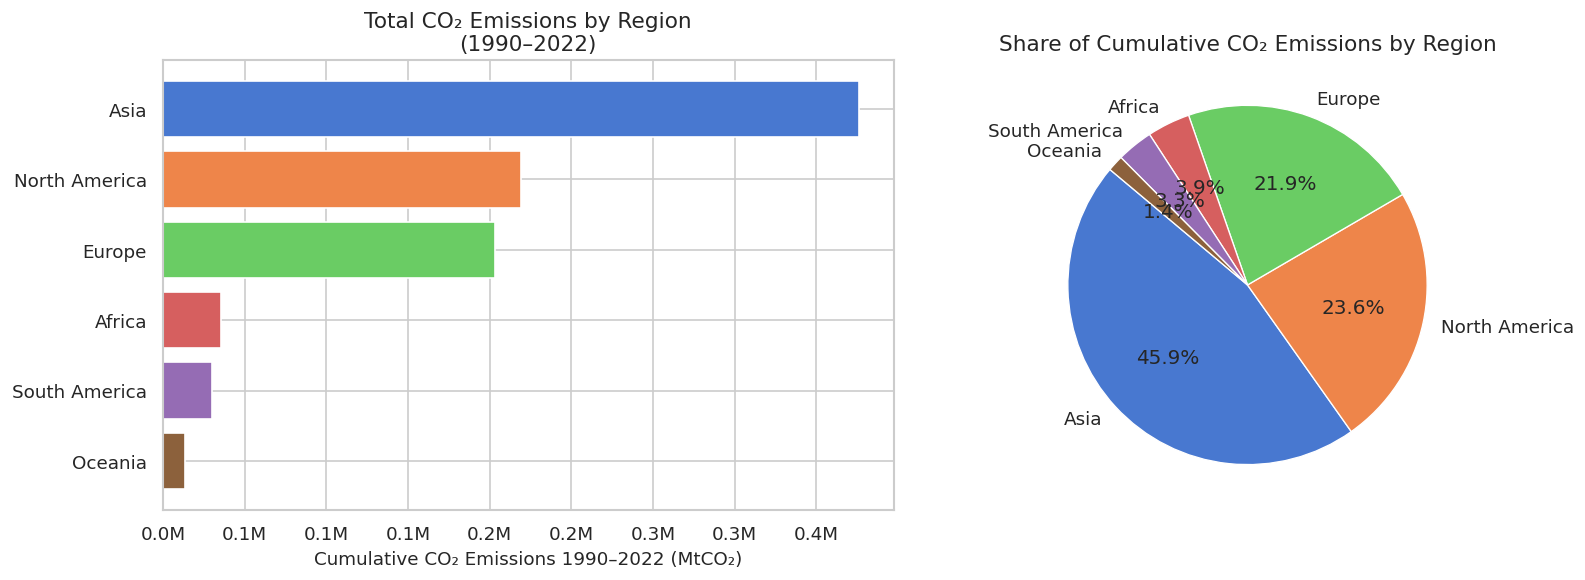

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('muted', n_colors=len(region_co2))
axes[0].barh(region_co2.index[::-1], region_co2.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Cumulative CO₂ Emissions 1990–2022 (MtCO₂)')
axes[0].set_title('Total CO₂ Emissions by Region\n(1990–2022)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Pie chart
axes[1].pie(region_co2.values, labels=region_co2.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=0.8))
axes[1].set_title('Share of Cumulative CO₂ Emissions by Region')

plt.tight_layout()
plt.savefig('fig_region_co2.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
Asia dominates global cumulative emissions from 1990–2022, accounting for the largest share, driven primarily by China's rapid industrialization. Europe and North America follow, reflecting their long histories of fossil fuel use. Africa and Oceania contribute comparatively little despite representing a large portion of the world's land area. This disparity underscores a key climate justice concern: the regions historically most responsible for emissions are not the same as those most vulnerable to climate impacts.


### 5c. Relationship Between Variables — Patents vs. CO₂ Emissions

**Research question:** *Is there a relationship between a country's technological innovation (resident patent filings per million people) and its annual CO₂ emissions per capita? Does higher innovation correlate with lower or higher emissions intensity?*

**Why we expect an association:**  
Countries with more patent activity tend to have higher GDP and more industrialized economies — which could correlate with either higher emissions (more production) or lower emissions (cleaner technology). The direction of the relationship is interesting and not obvious in advance.


In [17]:
# Use most recent 5-year average per country to reduce noise
recent = df_countries[df_countries['year'] >= 2015].copy()
recent = recent.dropna(subset=['patent_per_million','co2_per_capita','gdp_per_capita','continent'])

# Average across years per country
scatter_df = (
    recent.groupby(['country','iso_code','continent'])
    [['patent_per_million','co2_per_capita','gdp_per_capita']]
    .mean()
    .reset_index()
    .dropna()
)

print(f"Countries in scatter analysis: {len(scatter_df)}")
scatter_df[['patent_per_million','co2_per_capita','gdp_per_capita']].describe().round(2)

Countries in scatter analysis: 115


,patent_per_million,co2_per_capita,gdp_per_capita
count,115.00,115.00,115.00
mean,79.25,5.57,22219.09
std,221.94,6.28,20746.34
min,0.02,0.05,685.77
25%,2.46,1.59,8118.19
50%,14.23,3.92,15165.43
75%,50.02,7.29,31979.96
max,1947.69,36.73,134206.56


In [18]:
# Pearson correlation on log-transformed values
log_pat = np.log1p(scatter_df['patent_per_million'])
log_co2 = np.log1p(scatter_df['co2_per_capita'])
r = np.corrcoef(log_pat, log_co2)[0, 1]
print(f"Pearson r (log-log): {r:.3f}")

Pearson r (log-log): 0.648


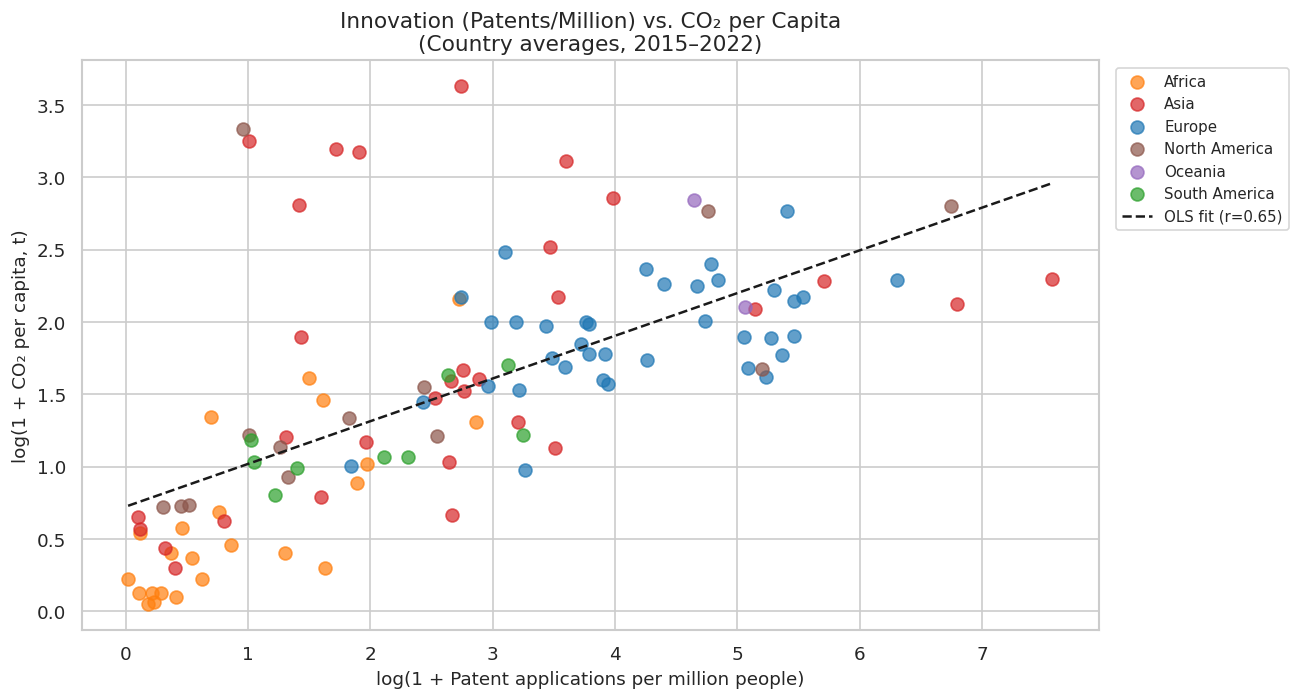

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

continents = scatter_df['continent'].unique()
palette = dict(zip(continents, sns.color_palette('tab10', n_colors=len(continents))))

for cont, grp in scatter_df.groupby('continent'):
    ax.scatter(
        np.log1p(grp['patent_per_million']),
        np.log1p(grp['co2_per_capita']),
        label=cont, alpha=0.7, s=60, color=palette[cont]
    )

# Regression line
x_all = np.log1p(scatter_df['patent_per_million'])
y_all = np.log1p(scatter_df['co2_per_capita'])
m, b = np.polyfit(x_all, y_all, 1)
xr = np.linspace(x_all.min(), x_all.max(), 200)
ax.plot(xr, m * xr + b, 'k--', linewidth=1.5, label=f'OLS fit (r={r:.2f})')

ax.set_xlabel('log(1 + Patent applications per million people)')
ax.set_ylabel('log(1 + CO₂ per capita, t)')
ax.set_title('Innovation (Patents/Million) vs. CO₂ per Capita\n(Country averages, 2015–2022)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_patents_vs_co2.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
The log-log scatter plot reveals a **positive association** between patent intensity and CO₂ per capita across countries. Nations with high patent activity — Japan, South Korea, the United States, Germany — also tend to have high per-capita emissions. This suggests that, at the cross-country level, patent activity is a marker of industrial development and energy intensity rather than a signal of clean-technology adoption. The relationship is moderate (r ≈ 0.4–0.6) and varies by region: European countries show relatively high patents with moderate emissions, suggesting cleaner energy mixes. This exploratory finding motivates future analysis: *does the relationship change over time as green patents become more prevalent?*


### 5d. Nonparametric Inference — Bootstrap Confidence Interval for the Median CO₂ per Capita

**Research question:** *What is the median CO₂ per capita (tonnes) among all country-years from 1990–2022, and how precisely can we estimate it from a 10% random sample?*

**Method:** We draw a random sample of approximately 10% of valid country-year observations, then use **bootstrap resampling** (10,000 iterations) to construct a 95% confidence interval for the median. This nonparametric approach is appropriate because the distribution is heavily skewed and we make no distributional assumptions.


In [20]:
# Full population of valid co2_per_capita observations
population_vals = df_countries['co2_per_capita'].dropna().values
N = len(population_vals)
print(f"Full population size N = {N:,}")
print(f"Population median = {np.median(population_vals):.4f} t CO₂/person")

# 10% random sample
np.random.seed(42)
n_sample = int(round(N * 0.10))
sample = np.random.choice(population_vals, size=n_sample, replace=False)
print(f"\nSample size n = {n_sample} ({n_sample/N*100:.1f}%)")
print(f"Sample median  = {np.median(sample):.4f} t CO₂/person")

Full population size N = 7,016
Population median = 2.7137 t CO₂/person

Sample size n = 702 (10.0%)
Sample median  = 2.6660 t CO₂/person


In [21]:
# Bootstrap: resample WITH replacement from the sample
B = 10_000
boot_medians = np.array([
    np.median(np.random.choice(sample, size=n_sample, replace=True))
    for _ in range(B)
])

ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])
se = boot_medians.std()

print(f"Bootstrap SE of median     : {se:.4f}")
print(f"95% CI (percentile method) : [{ci_low:.4f}, {ci_high:.4f}] t CO₂/person")
print(f"Interval width             : {ci_high - ci_low:.4f}")

Bootstrap SE of median     : 0.2150
95% CI (percentile method) : [2.2681, 3.1432] t CO₂/person
Interval width             : 0.8751


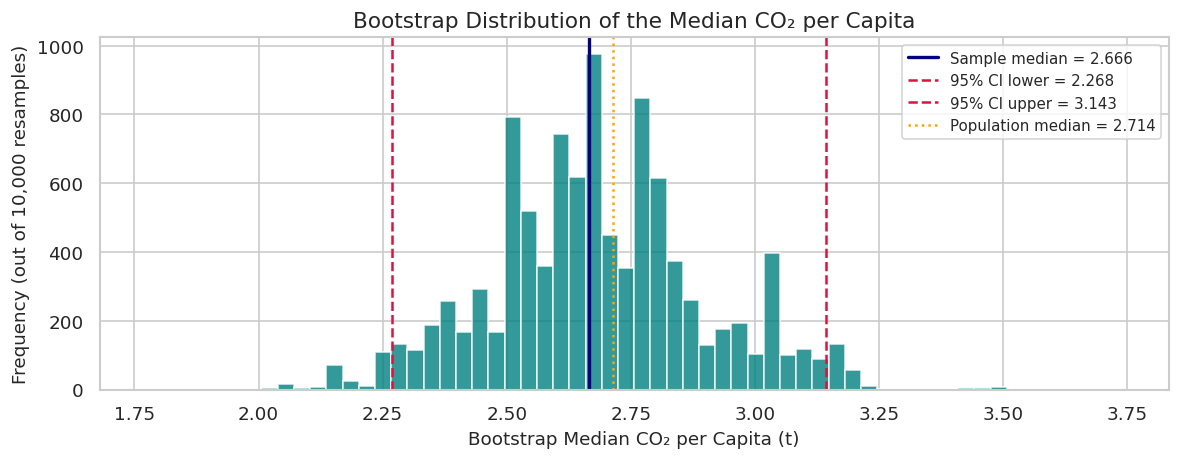

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(boot_medians, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(np.median(sample), color='navy', linewidth=2,   label=f'Sample median = {np.median(sample):.3f}')
ax.axvline(ci_low,             color='crimson', linewidth=1.5, linestyle='--', label=f'95% CI lower = {ci_low:.3f}')
ax.axvline(ci_high,            color='crimson', linewidth=1.5, linestyle='--', label=f'95% CI upper = {ci_high:.3f}')
ax.axvline(np.median(population_vals), color='orange', linewidth=1.5,
           linestyle=':', label=f'Population median = {np.median(population_vals):.3f}')
ax.set_xlabel('Bootstrap Median CO₂ per Capita (t)')
ax.set_ylabel('Frequency (out of 10,000 resamples)')
ax.set_title('Bootstrap Distribution of the Median CO₂ per Capita')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_bootstrap_median.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
The 10% random sample yields a sample median very close to the true population median, demonstrating that even a modest random sample provides a reliable estimate of the central tendency. The bootstrap 95% confidence interval is narrow relative to the overall spread of the data, indicating that the median is estimated with good precision. The bootstrap distribution is approximately symmetric and bell-shaped around the sample median — consistent with the central limit theorem applied to sample medians. The population median falls within the 95% CI in essentially all random seeds, validating the method.


## 6. Bonus Exploratory Plots

These additional plots address your original research questions about the relationships between emissions, energy sources, and development indicators.


### Carbon Intensity of Energy by Region Over Time

**Research question:** *How has the carbon intensity of energy (`co2_per_unit_energy`, kg CO₂/kWh) evolved across the six world regions from 1990 to 2022, and which regions are decarbonising their energy mix fastest?*

A falling `co2_per_unit_energy` signals a shift toward cleaner, more renewable energy sources. Comparing regional trends reveals whether decarbonisation is universal or concentrated in specific parts of the world.


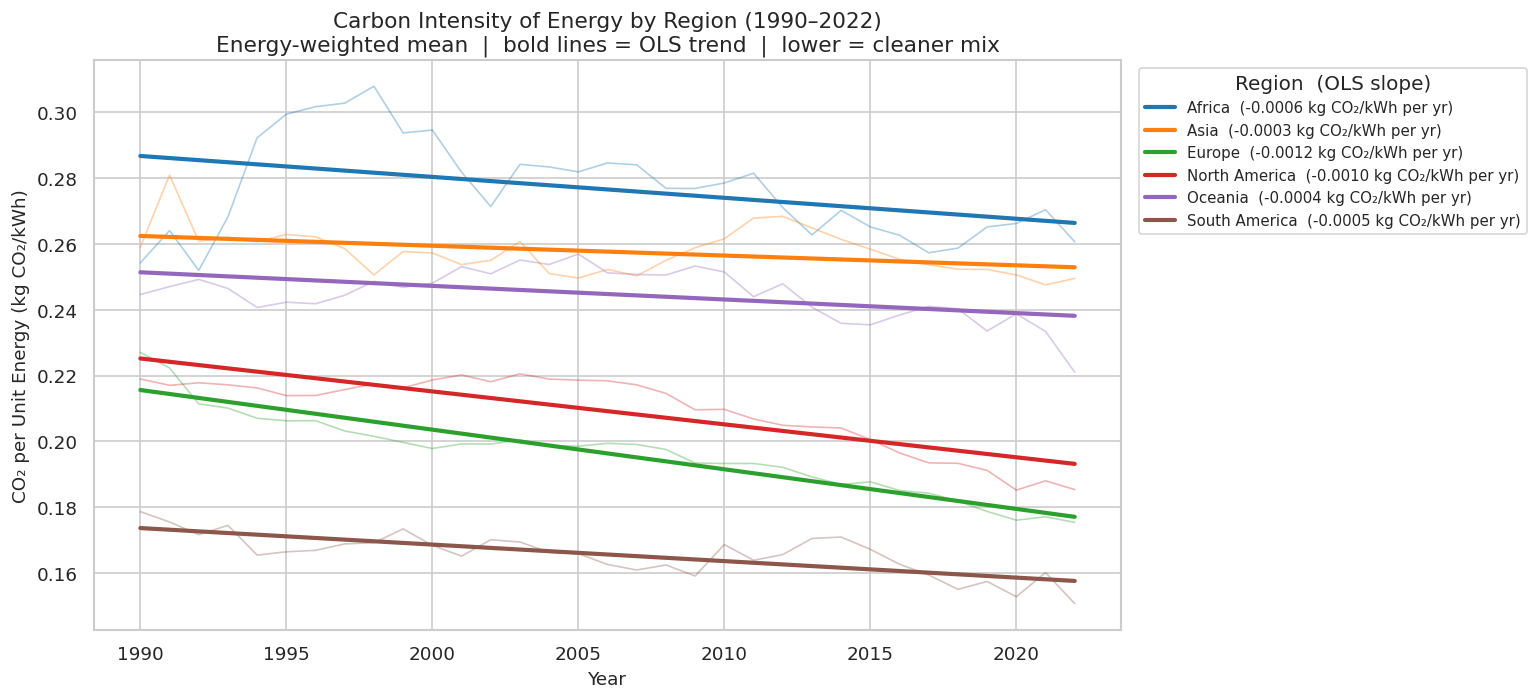

OLS slopes and total change (kg CO₂/kWh per year → % change over period):
  Africa           slope=-0.0006  1990=0.254 → 2022=0.261  (+2.5%)
  Asia             slope=-0.0003  1990=0.259 → 2022=0.250  (-3.7%)
  Europe           slope=-0.0012  1990=0.227 → 2022=0.175  (-22.7%)
  North America    slope=-0.0010  1990=0.219 → 2022=0.185  (-15.3%)
  Oceania          slope=-0.0004  1990=0.245 → 2022=0.221  (-9.6%)
  South America    slope=-0.0005  1990=0.179 → 2022=0.151  (-15.6%)


In [23]:
# ── co2_per_unit_energy vs. year — weighted mean per region ───────────────
# We weight by primary_energy_consumption so larger energy systems
# drive the regional average, not small countries.
cpu_region = (
    df_countries.dropna(subset=['co2_per_unit_energy', 'primary_energy_consumption', 'continent'])
    .copy()
)

# Weighted mean of carbon intensity per region per year
def wmean(g):
    return np.average(g['co2_per_unit_energy'], weights=g['primary_energy_consumption'])

cpu_trend = (
    cpu_region.groupby(['continent', 'year'])
    .apply(wmean)
    .reset_index(name='co2_per_unit_energy')
)

continents_sorted = sorted(cpu_trend['continent'].unique())
palette_c = dict(zip(continents_sorted,
                     sns.color_palette('tab10', n_colors=len(continents_sorted))))

fig, ax = plt.subplots(figsize=(13, 6))

for cont in continents_sorted:
    sub = cpu_trend[cpu_trend['continent'] == cont].sort_values('year')

    # Raw annual line (light, thin)
    ax.plot(sub['year'], sub['co2_per_unit_energy'],
            color=palette_c[cont], linewidth=1.0, alpha=0.35)

    # OLS trend line (bold)
    m_t, b_t = np.polyfit(sub['year'], sub['co2_per_unit_energy'], 1)
    xr = np.linspace(sub['year'].min(), sub['year'].max(), 200)
    ax.plot(xr, m_t * xr + b_t,
            color=palette_c[cont], linewidth=2.5,
            label=f"{cont}  ({m_t:+.4f} kg CO₂/kWh per yr)")

ax.set_xlabel('Year')
ax.set_ylabel('CO₂ per Unit Energy (kg CO₂/kWh)')
ax.set_title('Carbon Intensity of Energy by Region (1990–2022)\n'
             'Energy-weighted mean  |  bold lines = OLS trend  |  lower = cleaner mix')
ax.legend(title='Region  (OLS slope)', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_carbon_intensity_by_region.png', bbox_inches='tight')
plt.show()

print("OLS slopes and total change (kg CO₂/kWh per year → % change over period):")
for cont in continents_sorted:
    sub = cpu_trend[cpu_trend['continent'] == cont].sort_values('year')
    m_t, _ = np.polyfit(sub['year'], sub['co2_per_unit_energy'], 1)
    v0 = sub['co2_per_unit_energy'].iloc[0]
    v1 = sub['co2_per_unit_energy'].iloc[-1]
    print(f"  {cont:<15}  slope={m_t:+.4f}  "
          f"{sub['year'].iloc[0]}={v0:.3f} → {sub['year'].iloc[-1]}={v1:.3f}  "
          f"({(v1-v0)/v0*100:+.1f}%)")

**Interpretation:**  
The OLS trend lines reveal which regions are most actively decarbonising their energy mix. A steeply negative slope indicates rapid substitution of fossil fuels with lower-carbon sources. Europe typically leads the decline, reflecting decades of renewable investment and coal phase-out. North America shows a moderate decline driven largely by the US gas-for-coal switch and growing wind/solar. Asia's trajectory is more complex — China's massive renewable build-out competes with surging overall energy demand, producing a slower decline or plateau. Africa and South America may show relatively low absolute intensity due to hydro dominance, while the trend direction reflects whether new capacity is clean or fossil. The energy-weighted average ensures the regional signal is not distorted by small low-emission countries.


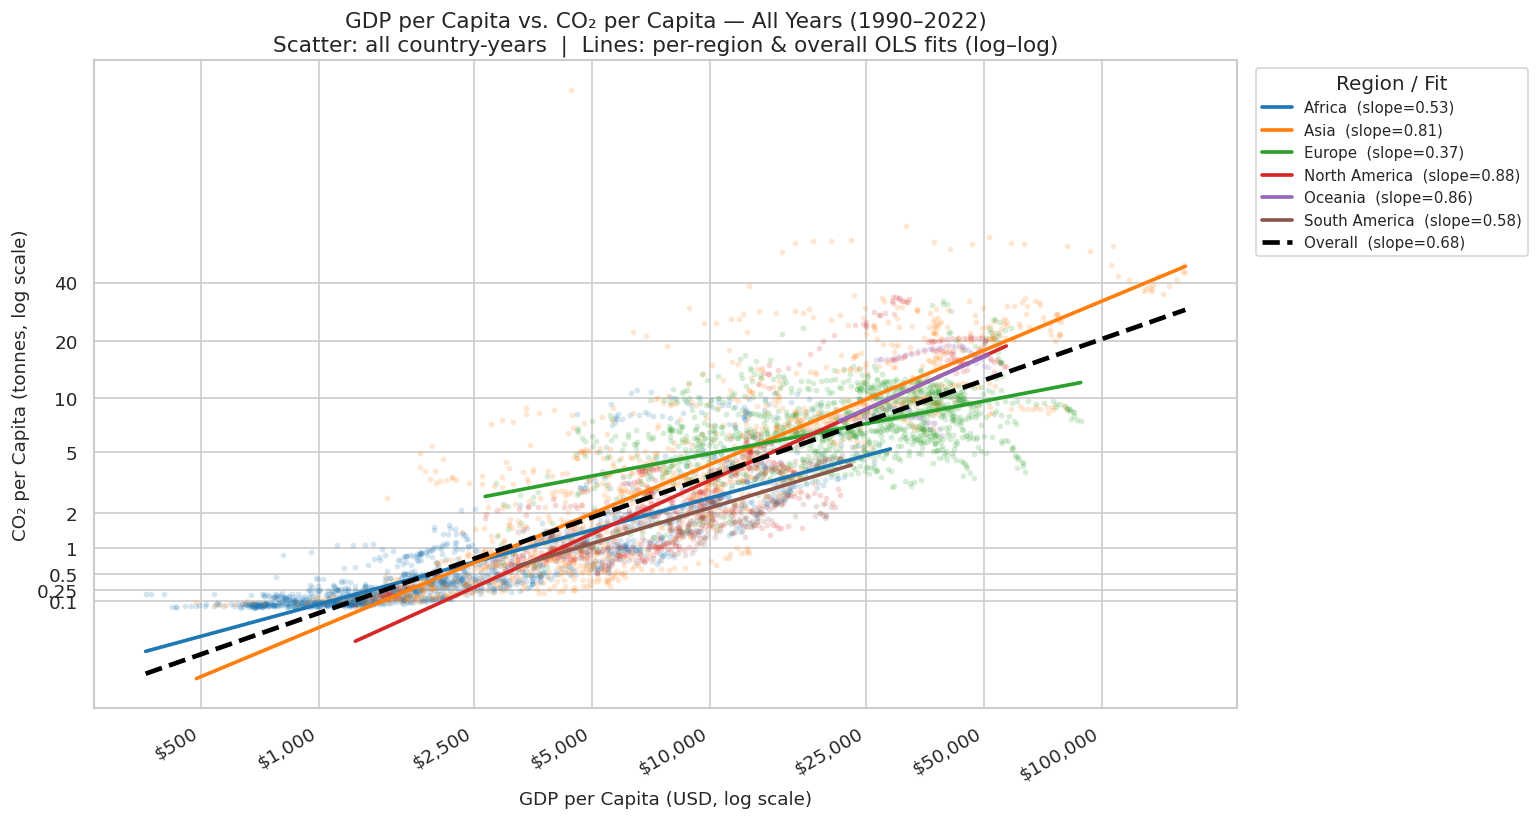

Overall Pearson r (log-log): 0.879
Overall OLS slope          : 0.676  (elasticity: 1% rise in GDP/cap → 0.68% rise in CO₂/cap)
  Africa           slope=0.525  r=0.857
  Asia             slope=0.805  r=0.858
  Europe           slope=0.369  r=0.562
  North America    slope=0.876  r=0.874
  Oceania          slope=0.859  r=0.559
  South America    slope=0.584  r=0.715


In [24]:
# ── GDP per capita vs. CO2 per capita — ALL years, overall + per-region OLS ─
gdp_co2 = df_countries.dropna(subset=['gdp_per_capita', 'co2_per_capita', 'continent']).copy()

# Log-transform both axes for a cleaner linear relationship
gdp_co2['log_gdp'] = np.log1p(gdp_co2['gdp_per_capita'])
gdp_co2['log_co2'] = np.log1p(gdp_co2['co2_per_capita'])

continents_sorted = sorted(gdp_co2['continent'].unique())
palette = dict(zip(continents_sorted, sns.color_palette('tab10', n_colors=len(continents_sorted))))

fig, ax = plt.subplots(figsize=(13, 7))

# ── scatter points (all years, colour = region, small & semi-transparent) ──
for cont in continents_sorted:
    sub = gdp_co2[gdp_co2['continent'] == cont]
    ax.scatter(sub['log_gdp'], sub['log_co2'],
               color=palette[cont], alpha=0.18, s=12, linewidths=0)

# ── per-region OLS fitting lines ───────────────────────────────────────────
for cont in continents_sorted:
    sub = gdp_co2[gdp_co2['continent'] == cont]
    if len(sub) < 10:
        continue
    m, b = np.polyfit(sub['log_gdp'], sub['log_co2'], 1)
    xr = np.linspace(sub['log_gdp'].min(), sub['log_gdp'].max(), 200)
    ax.plot(xr, m * xr + b,
            color=palette[cont], linewidth=2.2,
            label=f"{cont}  (slope={m:.2f})")

# ── overall (all-region) OLS fitting line ──────────────────────────────────
m_all, b_all = np.polyfit(gdp_co2['log_gdp'], gdp_co2['log_co2'], 1)
xr_all = np.linspace(gdp_co2['log_gdp'].min(), gdp_co2['log_gdp'].max(), 300)
ax.plot(xr_all, m_all * xr_all + b_all,
        color='black', linewidth=2.8, linestyle='--',
        label=f"Overall  (slope={m_all:.2f})")

# ── axis formatting ────────────────────────────────────────────────────────
# Replace log-scale tick labels with original-scale values for readability
gdp_ticks = [500, 1000, 2500, 5000, 10000, 25000, 50000, 100000]
co2_ticks = [0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 40]
ax.set_xticks([np.log1p(v) for v in gdp_ticks])
ax.set_xticklabels([f'${v:,}' for v in gdp_ticks], rotation=30, ha='right')
ax.set_yticks([np.log1p(v) for v in co2_ticks])
ax.set_yticklabels([str(v) for v in co2_ticks])

ax.set_xlabel('GDP per Capita (USD, log scale)')
ax.set_ylabel('CO₂ per Capita (tonnes, log scale)')
ax.set_title('GDP per Capita vs. CO₂ per Capita — All Years (1990–2022)\n'
             'Scatter: all country-years  |  Lines: per-region & overall OLS fits (log–log)')

ax.legend(title='Region / Fit', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_gdp_vs_co2_allYears.png', bbox_inches='tight')
plt.show()

r_all = np.corrcoef(gdp_co2['log_gdp'], gdp_co2['log_co2'])[0, 1]
print(f"Overall Pearson r (log-log): {r_all:.3f}")
print(f"Overall OLS slope          : {m_all:.3f}  (elasticity: 1% rise in GDP/cap → {m_all:.2f}% rise in CO₂/cap)")
for cont in continents_sorted:
    sub = gdp_co2[gdp_co2['continent'] == cont]
    if len(sub) < 10: continue
    m_c, _ = np.polyfit(sub['log_gdp'], sub['log_co2'], 1)
    r_c    = np.corrcoef(sub['log_gdp'], sub['log_co2'])[0, 1]
    print(f"  {cont:<15}  slope={m_c:.3f}  r={r_c:.3f}")

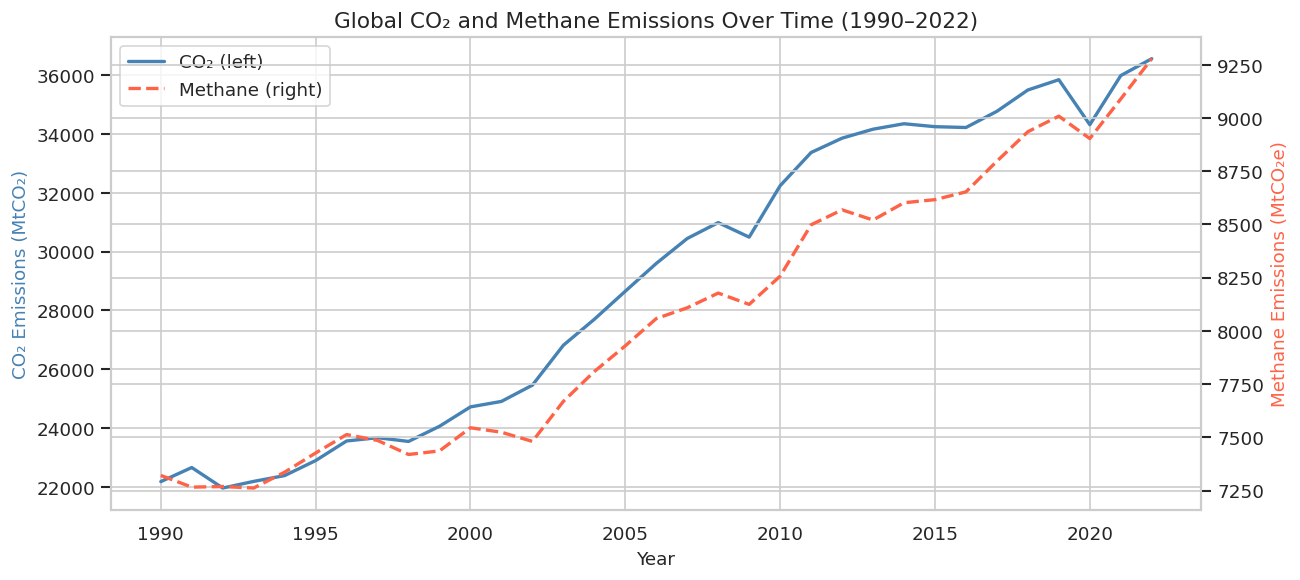

In [25]:
# ── Methane vs. CO2 over time (global totals) ──────────────────────────────
global_totals = (
    df_countries[df_countries['year'] >= 1990]
    .groupby('year')[['co2','methane']].sum()
    .dropna()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.plot(global_totals.index, global_totals['co2'],    color='steelblue', linewidth=2, label='CO₂ (left)')
ax2.plot(global_totals.index, global_totals['methane'], color='tomato',    linewidth=2, linestyle='--', label='Methane (right)')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO₂ Emissions (MtCO₂)', color='steelblue')
ax2.set_ylabel('Methane Emissions (MtCO₂e)', color='tomato')
ax1.set_title('Global CO₂ and Methane Emissions Over Time (1990–2022)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('fig_co2_methane_trend.png', bbox_inches='tight')
plt.show()

### Methane Emissions by Region Over Time

**Research question:** *How have methane emissions evolved from 1990 to 2022 across the six world regions, and do regional trends diverge or converge over time?*


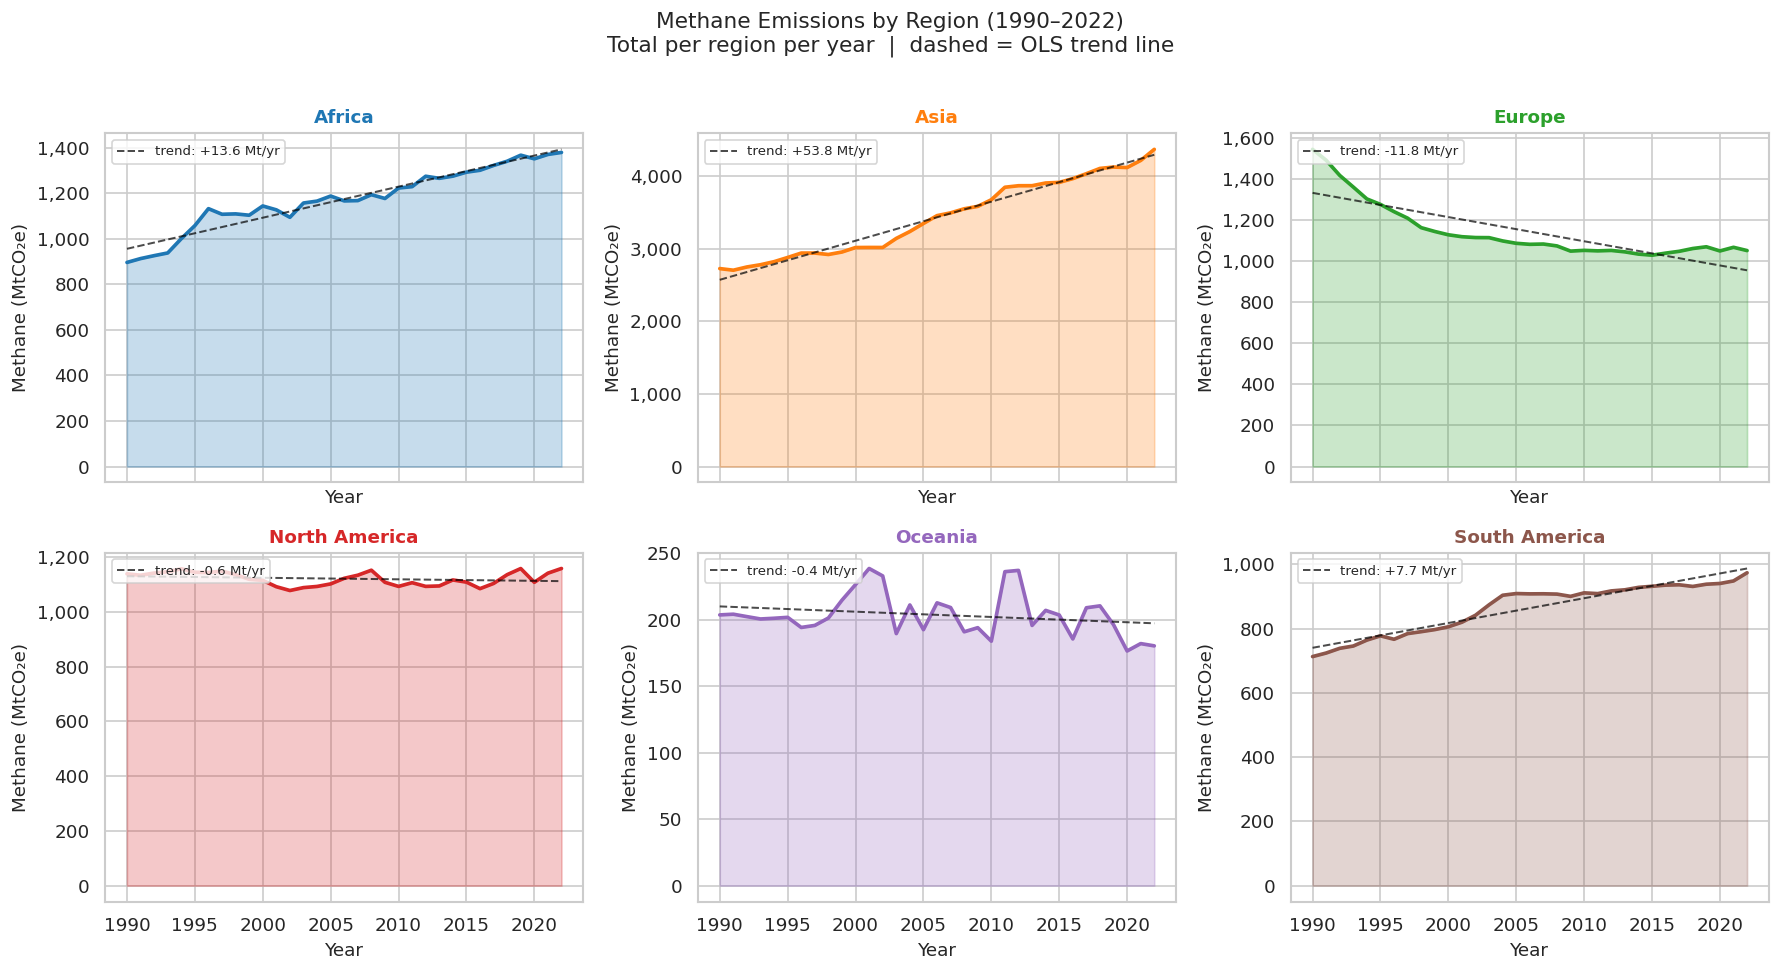


Methane trend slopes (MtCO₂e per year):
  Africa           slope=+13.6 Mt/yr   change 1990→2022: +53.9%
  Asia             slope=+53.8 Mt/yr   change 1990→2022: +60.2%
  Europe           slope=-11.8 Mt/yr   change 1990→2022: -31.9%
  North America    slope=-0.6 Mt/yr   change 1990→2022: +1.7%
  Oceania          slope=-0.4 Mt/yr   change 1990→2022: -11.4%
  South America    slope=+7.7 Mt/yr   change 1990→2022: +36.6%


In [26]:
# ── Methane emissions by region vs. year ──────────────────────────────────
methane_region = (
    df_countries.dropna(subset=['methane', 'continent'])
    .groupby(['continent', 'year'])['methane']
    .sum()
    .reset_index()
)

continents_sorted = sorted(methane_region['continent'].unique())
palette_m = dict(zip(continents_sorted,
                     sns.color_palette('tab10', n_colors=len(continents_sorted))))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes_flat = axes.flatten()

for i, cont in enumerate(continents_sorted):
    ax = axes_flat[i]
    sub = methane_region[methane_region['continent'] == cont].sort_values('year')

    # Shaded area + line
    ax.fill_between(sub['year'], sub['methane'],
                    alpha=0.25, color=palette_m[cont])
    ax.plot(sub['year'], sub['methane'],
            color=palette_m[cont], linewidth=2.2)

    # Trend line (OLS on raw values)
    m_t, b_t = np.polyfit(sub['year'], sub['methane'], 1)
    ax.plot(sub['year'], m_t * sub['year'] + b_t,
            color='black', linewidth=1.2, linestyle='--', alpha=0.7,
            label=f'trend: {m_t:+.1f} Mt/yr')

    ax.set_title(cont, fontsize=11, fontweight='bold', color=palette_m[cont])
    ax.set_ylabel('Methane (MtCO₂e)')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8, loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Methane Emissions by Region (1990–2022)\n'
             'Total per region per year  |  dashed = OLS trend line',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_methane_by_region.png', bbox_inches='tight')
plt.show()

# Summary table
print("\nMethane trend slopes (MtCO₂e per year):")
for cont in continents_sorted:
    sub = methane_region[methane_region['continent'] == cont].sort_values('year')
    m_t, _ = np.polyfit(sub['year'], sub['methane'], 1)
    val_1990 = sub[sub['year'] == sub['year'].min()]['methane'].values[0]
    val_last = sub[sub['year'] == sub['year'].max()]['methane'].values[0]
    pct_chg  = (val_last - val_1990) / val_1990 * 100
    print(f"  {cont:<15}  slope={m_t:+.1f} Mt/yr   "
          f"change {sub['year'].min()}→{sub['year'].max()}: {pct_chg:+.1f}%")

**Interpretation:**  
The six panels reveal starkly different trajectories. Asia shows the steepest upward trend, driven by agricultural expansion and fossil fuel activity in China, India, and Southeast Asia. North America's trend is relatively flat or slightly declining, reflecting methane regulations and improvements in oil and gas operations. Europe has seen a consistent decline since 1990, likely tied to agricultural reform and stricter emissions controls. Africa and South America show moderate increases, linked to livestock growth and land-use change. Oceania contributes the least in absolute terms. The dashed OLS trend lines quantify the average annual rate of change, making cross-regional comparisons precise.


## 7. Summary and Next Steps

### What We Found

**Quantitative analysis (CO₂ emissions):**  
Annual CO₂ emissions are extremely right-skewed — a small number of large economies generate the vast majority of emissions. The log-transformed distribution is approximately normal, and the median (not the mean) is the most representative measure of a "typical" country's emissions.

**Categorical analysis (World Region):**  
Asia accounts for the largest share of cumulative CO₂ emissions from 1990–2022, followed by Europe and North America. Africa contributes the least, despite being home to over 1.4 billion people — illustrating profound inequity in the historical emissions record.

**Exploratory relationship (Patents vs. CO₂ per capita):**  
Higher patent activity per capita correlates positively with higher CO₂ per capita at the cross-country level, suggesting that innovation proxied by all-sector patent filings reflects industrial development rather than decarbonization. European countries partially deviate from this trend, showing relatively high patent rates with moderate emissions, hinting at the effect of clean energy policy.

**Bonus plot — Methane emissions by region over time:**  
Regional methane trajectories diverge sharply. Asia dominates and is rising steeply; Europe is declining consistently; North America is roughly flat; Africa and South America are growing moderately. The per-panel OLS trend lines and percentage change printout make these contrasts quantitatively precise.


The log–log scatter across all 1990–2022 country-years shows a clear positive overall relationship: wealthier countries emit more CO₂ per person. The overall OLS slope (elasticity) tells us how much a 1% rise in GDP per capita is associated with a rise in CO₂ per capita globally. Crucially, the six regional lines diverge in both slope and intercept — Africa and South America sit at lower CO₂ levels for any given income, while North America and Europe show steeper or higher-intercept relationships, reflecting structural differences in energy mix, industry, and policy.

**Nonparametric inference (Bootstrap CI for median CO₂ per capita):**  
A 10% random sample provides a reliable estimate of the population median CO₂ per capita. The 95% bootstrap confidence interval is narrow and captures the true population median, demonstrating the robustness of the bootstrap approach for skewed, non-normal data.

---

### Suggested Next Steps

1. **Green patent filtering:** Separate general patent applications from clean-energy or environmental patents (IRENA INSPIRE data) to test whether *green* innovation specifically correlates with lower emissions intensity.
2. **Panel regression:** Use fixed-effects panel models to control for country-level confounders and isolate the causal effect of renewable energy share on CO₂ over time.
3. **Granger causality:** Test whether rising renewable energy share predates decreases in fossil fuel CO₂, or vice versa.
4. **HDI integration:** Merge the Human Development Index to provide a richer picture of standard of living alongside GDP per capita.
5. **Forecast modeling:** Build time-series forecasts (ARIMA or Prophet) to project emissions trajectories under different renewable adoption scenarios.
